# Visualizing Maps with Large Numbers of Robots

3/14/2026

In [1]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

In [ ]:
import pickle
import ael.problem
import numpy as np

def load_instance(instance):
    obstacle_data, agent_data = instance

    agent_start_positions = []
    agent_end_positions = []
    agent_radii = []
    circular_obstacle_positions = []
    circular_obstacle_radii = []
    axis_aligned_box_obstacle_bounds = []

    for obstacle in obstacle_data:
        match obstacle:
            case (center, radius):
                circular_obstacle_positions.append(center)
                circular_obstacle_radii.append(radius)
            case (p1, _, p3, _):
                lower_bound = (min(p1[0], p3[0]), min(p1[1], p3[1]))
                upper_bound = (max(p1[0], p3[0]), max(p1[1], p3[1]))
                axis_aligned_box_obstacle_bounds.append((lower_bound, upper_bound))

    for start, end, radius in agent_data:
        agent_start_positions.append(start)
        agent_end_positions.append(end)
        agent_radii.append(radius)

    problem = ael.problem.Problem(
        num_timesteps=64,
        agent_radii=np.array(agent_radii),
        agent_max_speeds=0.05 * np.ones(len(agent_radii)),
        agent_start_positions=np.array(agent_start_positions),
        agent_end_positions=np.array(agent_end_positions),
        agent_reference_trajectory=None,
        circular_obstacle_positions=np.array(circular_obstacle_positions),
        circular_obstacle_radii=np.array(circular_obstacle_radii),
        axis_aligned_box_obstacle_bounds=np.array(axis_aligned_box_obstacle_bounds),
    )

    return problem



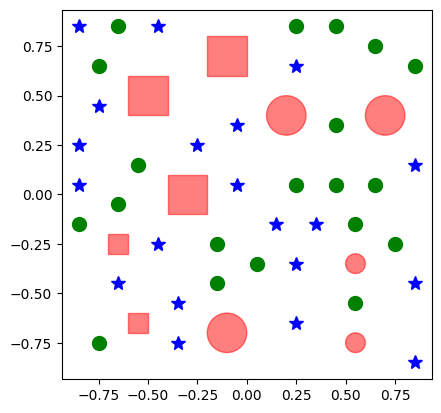

In [ ]:
import ael.visualize
import matplotlib.pyplot as plt

with open("../instances_data/larger/basic_maps.pkl", "rb") as f:
    data = pickle.load(f)

instance = data[0]

ael.visualize.visualize(load_instance(data[20]), plt.gca())
plt.show()